In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

==== Simulação ChargeGrid Inteligente ====


Hora: 0h
Tarifa base: R$ 0.70/kWh
Carro 3 | Rápida (DC) | Demanda: 33 kW | Recebido: 33 kW | Tempo: 0.66h | Custo: R$ 34.65
Carro 4 | Rápida (DC) | Demanda: 31 kW | Recebido: 31 kW | Tempo: 0.62h | Custo: R$ 32.55
Carro 5 | Semirrápida (AC) | Demanda: 31 kW | Recebido: 31 kW | Tempo: 1.41h | Custo: R$ 21.70
Carro 2 | Semirrápida (AC) | Demanda: 22 kW | Recebido: 5 kW | Tempo: 0.23h | Custo: R$ 3.50
Carro 1 | Rápida (DC) | Demanda: 21 kW | Recebido: 0 kW | Tempo: 0.00h | Custo: R$ 0.00
Tempo médio: 0.58h
Energia restante: 0 kW

Hora: 1h
Tarifa base: R$ 0.70/kWh
Carro 4 | Semirrápida (AC) | Demanda: 34 kW | Recebido: 34 kW | Tempo: 1.55h | Custo: R$ 23.80
Carro 1 | Rápida (DC) | Demanda: 33 kW | Recebido: 33 kW | Tempo: 0.66h | Custo: R$ 34.65
Carro 2 | Semirrápida (AC) | Demanda: 32 kW | Recebido: 32 kW | Tempo: 1.45h | Custo: R$ 22.40
Carro 5 | Rápida (DC) | Demanda: 28 kW | Recebido: 1 kW | Tempo: 0.02h | Custo: R$ 1.05
Carro 3 | Rápida (DC

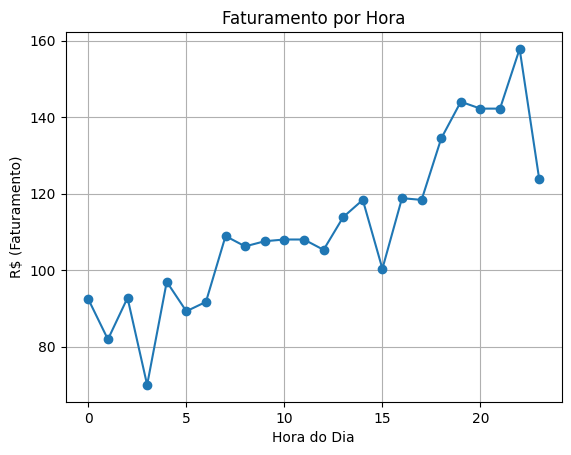

In [10]:
import random

# ----------
# Configurações
# ----------

TOTAL_ENERGIA = 100
NUM_CARROS = 5
HORAS = list(range(24))

# Tarifas (aumentadas)
TARIFA_BASE = 0.90
TARIFA_PICO = 1.20
TARIFA_BAIXA = 0.70

MULT_RAPIDA = 1.5
MULT_SEMIRRAPIDA = 1.0

POTENCIA_RAPIDA = 50
POTENCIA_SEMIRRAPIDA = 22

# ----------
# Funções
# ----------

def definir_tarifa(hora):
    if 18 <= hora <= 22:
        return TARIFA_PICO
    elif 0 <= hora <= 6:
        return TARIFA_BAIXA
    return TARIFA_BASE


def criar_carro(id):
    demanda = random.randint(10, 40)
    tipo = random.choice(["rapida", "semirrapida"])

    if tipo == "rapida":
        return {
            "id": id,
            "demanda": demanda,
            "tipo": tipo,
            "potencia": POTENCIA_RAPIDA,
            "multiplicador": MULT_RAPIDA,
            "energia_recebida": 0
        }
    else:
        return {
            "id": id,
            "demanda": demanda,
            "tipo": tipo,
            "potencia": POTENCIA_SEMIRRAPIDA,
            "multiplicador": MULT_SEMIRRAPIDA,
            "energia_recebida": 0
        }


def distribuir_energia(carros, energia_total):
    energia_restante = energia_total

    for carro in carros:
        if energia_restante <= 0:
            break

        energia = min(carro["demanda"], energia_restante)
        carro["energia_recebida"] = energia
        energia_restante -= energia

    return energia_restante


def calcular_metricas(carros, tarifa_base):
    tempos = []
    total_hora = 0

    for carro in carros:
        tarifa_final = tarifa_base * carro["multiplicador"]
        custo = carro["energia_recebida"] * tarifa_final

        carro["custo"] = custo
        total_hora += custo

        if carro["energia_recebida"] > 0:
            tempo = carro["energia_recebida"] / carro["potencia"]
        else:
            tempo = 0

        carro["tempo"] = tempo
        tempos.append(tempo)

    tempo_medio = sum(tempos) / len(tempos)
    return tempo_medio, total_hora


def exibir_resultados(hora, carros, tarifa, energia_restante, tempo_medio):
    print(f"\nHora: {hora}h")
    print(f"Tarifa base: R$ {tarifa:.2f}/kWh")

    for carro in carros:
        tipo = "Rápida (DC)" if carro["tipo"] == "rapida" else "Semirrápida (AC)"

        print(
            f"Carro {carro['id']} | {tipo} | "
            f"Demanda: {carro['demanda']} kW | "
            f"Recebido: {carro['energia_recebida']} kW | "
            f"Tempo: {carro['tempo']:.2f}h | "
            f"Custo: R$ {carro['custo']:.2f}"
        )

    print(f"Tempo médio: {tempo_medio:.2f}h")
    print(f"Energia restante: {energia_restante} kW")


# ----------
# Programa Principal
# ----------

print("==== Simulação ChargeGrid Inteligente ====\n")

total_dia = 0
faturamento_por_hora = []

for hora in HORAS:
    tarifa = definir_tarifa(hora)

    carros = [criar_carro(i + 1) for i in range(NUM_CARROS)]
    carros.sort(key=lambda x: x["demanda"], reverse=True)

    energia_restante = distribuir_energia(carros, TOTAL_ENERGIA)

    tempo_medio, total_hora = calcular_metricas(carros, tarifa)

    total_dia += total_hora
    faturamento_por_hora.append(total_hora)

    exibir_resultados(hora, carros, tarifa, energia_restante, tempo_medio)

print("\n==== Fim da Simulação ====")
print(f"\nTotal arrecadado no dia: R$ {total_dia:.2f}")

# ----------
# Gráfico
# ----------

plt.figure()
plt.plot(HORAS, faturamento_por_hora, marker='o')
plt.title("Faturamento por Hora")
plt.xlabel("Hora do Dia")
plt.ylabel("R$ (Faturamento)")
plt.grid()

plt.show()